# S1 — Regularization demo

The regularization parameter **xlam** controls the smoothness prior applied to the
recovered LOSVD.  The penalty term added to the chi-squared objective is:

$$\mathcal{L}(b) = \chi^2 + \lambda \sum_i \left(\frac{d^2 b}{dv^2}\right)_i^2$$

- **Small xlam** → little smoothing → noisy LOSVD, low chi2 (overfitting)
- **Large xlam** → heavy smoothing → broadened LOSVD, higher chi2

The automatic selection (`xlam_auto=True`, `xlam_criterion='chi2'`) runs fits at
every grid point and picks the **largest xlam** whose chi2_red is within
`xlam_chi2_tolerance` (default 2%) of the grid minimum.  This means: *use as much
regularisation as possible while still fitting the data well.*

Roughness (`max|D²b|/peak`) is computed and logged at every grid point as a
diagnostic — it tells you whether the LOSVD is noisy or smooth — but it is
**not** used to select xlam.  The old roughness threshold (0.25) was unreliable
for broad LOSVDs ($\sigma$ > 80 km/s) because roughness drops below 0.25 at an
intermediate xlam that gives biased h3/h4 values.

This notebook runs 10 fits at fixed xlam values and shows how fit quality, LOSVD
shape, and recovered moments all change.

In [1]:
from __future__ import annotations
import tempfile
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, shift as ndimage_shift
from kinextract import FitConfig, run_spectral_fit
from kinextract.fitting import compute_losvd_roughness, fit_losvd_gauss_hermite



## 1. Generate synthetic data

In [2]:
WAVEMIN, STEP, N_PIX = 4750.0, 1.25, 3681
WAVEFITMIN, WAVEFITMAX = 8400.0, 8800.0
CEE, LAM_CENTER = 299792.458, 8580.0
TRUE_V, TRUE_SIGMA = 80.0, 140.0

wavelength = WAVEMIN + np.arange(N_PIX) * STEP
CA_DEPTHS  = [0.55, 0.70, 0.65]
template   = np.ones(N_PIX)
for cen, depth in zip([8498.02, 8542.09, 8662.14], CA_DEPTHS):
    template -= depth * np.exp(-0.5 * ((wavelength - cen) / 5.0) ** 2)

sigma_pix = TRUE_SIGMA * LAM_CENTER / (CEE * STEP)
shift_pix = TRUE_V    * LAM_CENTER / (CEE * STEP)

RNG  = np.random.default_rng(42)
gal  = ndimage_shift(gaussian_filter(template, sigma_pix), +shift_pix)
gal += RNG.normal(0.0, 0.02, N_PIX)
errs = np.full(N_PIX, 0.02)

tmpdir = Path(tempfile.mkdtemp(prefix='kinextract_reg_'))
np.savetxt(tmpdir / 'mock.spec',          np.column_stack([np.arange(1, N_PIX+1), gal, errs]),  fmt='%6d  %14.8f  %14.8f')
np.savetxt(tmpdir / 'mock_template.dat',  np.column_stack([wavelength, template, np.full(N_PIX, 0.001)]),  fmt='%10.4f  %14.8f  %12.8f')
(tmpdir / 'Tlist').write_text('mock_template.dat\n')
print('Data ready.')

Data ready.


## 2. Run fits at 10 fixed xlam values

This cell takes ~2 minutes. Reduce the grid or lower `map_maxiter` to speed it up.

In [3]:
XLAM_GRID      = [1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0, 1000000.0, 10000000.0, 100000000.0, 1000000000.0]
CHI2_TOLERANCE = 0.02   # matches xlam_chi2_tolerance default

results = []
for xlam in XLAM_GRID:
    cfg = FitConfig(
        template_list_file  = str(tmpdir / 'Tlist'),
        template_dir        = str(tmpdir),
        # outdir=str(tmpdir), write_outputs=True,  # uncomment to save .fit/.temp/.ascii/.rms output files
        wavemin_full        = WAVEMIN, step = STEP,
        wavefitmin          = WAVEFITMIN, wavefitmax = WAVEFITMAX,
        zgal                = 0.0, fit_als_continuum = False,
        xlam_auto = False, xlam = xlam,
        sigl = 100.0, use_spectrum_errors = True,
        clean = False, map_maxiter = 3000, print_every = 999999,
    )
    fit = run_spectral_fit(cfg, gal_file=str(tmpdir / 'mock.spec'))
    st  = fit['state']
    b   = fit['outputs']['b']
    r   = compute_losvd_roughness(b)
    chi = fit['outputs']['chi2_red']
    gh  = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
    rel = fit['result'].success
    results.append(dict(xlam=xlam, chi2_red=chi, roughness=r, b=b.copy(), xl=st.xl.copy(), gh=gh, success=rel))
    print(f'  xlam={xlam:>10.0f}  chi2_red={chi:.3f}  roughness={r:.4f}'
          f'  V={gh["vherm"]:+.1f}  σ={gh["sherm"]:.1f}  h3={gh["h3"]:+.4f}'
          f'{"" if rel else "  [unreliable]"}')

chi2_min    = min(r['chi2_red'] for r in results)
chi2_max_ok = chi2_min * (1.0 + CHI2_TOLERANCE)
auto_chi2   = next((r for r in reversed(results) if r['chi2_red'] <= chi2_max_ok), None)
print(f'\nchi2_min={chi2_min:.4f}  chi2_max_ok={chi2_max_ok:.4f}')
if auto_chi2:
    print(f'chi2 auto-pick: xlam={auto_chi2["xlam"]:.0f}')


[     0.90s] ==== spectral fitting START | /var/folders/zp/_mj2qgk5107f3gf_2gnw4gnm0000gs/T/kinextract_reg_io64zs2q/mock.spec ====


[     0.90s] wavefit=[8400.0, 8800.0] z=0.0 sigl=100.0 xlam=1.0


[     0.90s] fit_als_continuum=False prenorm=True


[     0.90s] START build FitState


[     0.90s] START read spectrum


...

[     9.71s] END   MAP optimize (1.35s)


[     9.71s] WARNING: optimizer reported: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT


[     9.71s] Final chi2=1227.38 ngood=319 xlam=1000000000.0


[     9.71s] ==== spectral fitting END ====


  xlam=1000000000  chi2_red=3.860  roughness=0.0171  V=+20.7  σ=228.1  h3=-0.0384  [unreliable]

chi2_min=0.9545  chi2_max_ok=0.9736
chi2 auto-pick: xlam=100000


## 3. Plot results

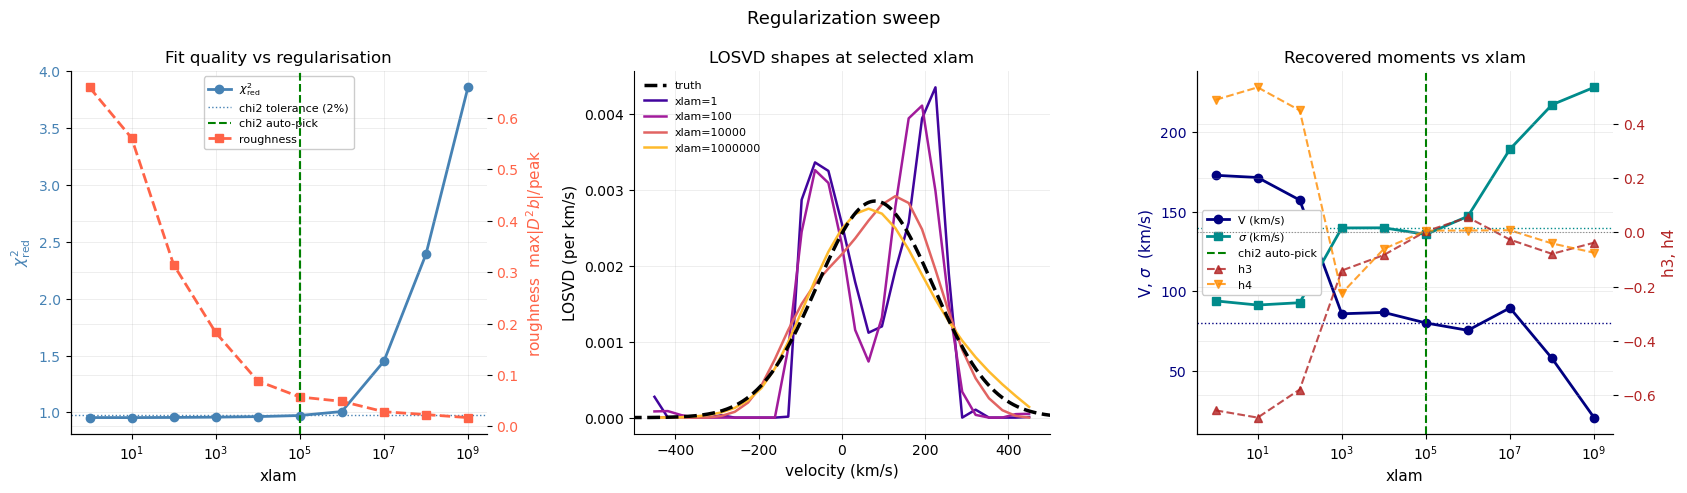

In [4]:
from scipy.integrate import trapezoid

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Regularization sweep', fontsize=13)

xlams = [r['xlam'] for r in results]

# Panel 1: chi2_red and roughness vs xlam
ax1 = axes[0]
ax2 = ax1.twinx()
ax1.semilogx(xlams, [r['chi2_red']  for r in results], 'o-', color='steelblue', lw=2, label=r'$\chi^2_{\rm red}$')
ax2.semilogx(xlams, [r['roughness'] for r in results], 's--', color='tomato', lw=2, label='roughness')
ax1.axhline(chi2_max_ok, color='steelblue', lw=1.0, ls=':', label=f'chi2 tolerance ({CHI2_TOLERANCE:.0%})')
if auto_chi2:
    ax1.axvline(auto_chi2['xlam'], color='green', lw=1.5, ls='--', label='chi2 auto-pick', zorder=0)
    ax2.axvline(auto_chi2['xlam'], color='green', lw=1.5, ls='--')
ax1.set_xlabel('xlam'); ax1.set_ylabel(r'$\chi^2_{\rm red}$', color='steelblue')
ax2.set_ylabel(r'roughness  max$|D^2 b|$/peak', color='tomato')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='tomato')
l1,n1 = ax1.get_legend_handles_labels()
l2,n2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, n1+n2, fontsize=8, frameon=True, framealpha=1.0, facecolor='white', loc='upper center').set_zorder(20)
ax1.set_title('Fit quality vs regularisation')

# Panel 2: LOSVD shapes
ax = axes[1]
v_dense = np.linspace(-600, 600, 801)
b_true_d = np.exp(-0.5 * ((v_dense - TRUE_V) / TRUE_SIGMA) ** 2)
b_true_d /= trapezoid(b_true_d, v_dense)
ax.plot(v_dense, b_true_d, lw=2.5, color='black', ls='--', label='truth', zorder=5)

show_idx = [0, 2, 4, 6]
colors   = plt.cm.plasma(np.linspace(0.1, 0.85, len(show_idx)))
for i, c in zip(show_idx, colors):
    r = results[i]
    ax.plot(r['xl'], r['b']/trapezoid(r['b'], r['xl']), lw=1.8, color=c,
            label=f"xlam={r['xlam']:.0f}")

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD (per km/s)')
ax.set_title('LOSVD shapes at selected xlam'); ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20); ax.set_xlim(-500, 500)

# Panel 3: recovered moments vs xlam
ax = axes[2]
ax3r = ax.twinx()
Vs     = [r['gh']['vherm'] for r in results]
sigmas = [r['gh']['sherm'] for r in results]
h3s    = [r['gh']['h3']    for r in results]
h4s    = [r['gh']['h4']    for r in results]
ax.semilogx(xlams, Vs,     'o-', color='navy',     lw=2, label='V (km/s)')
ax.semilogx(xlams, sigmas, 's-', color='darkcyan',  lw=2, label=r'$\sigma$ (km/s)')
ax.axhline(TRUE_V,     color='navy',    lw=1.0, ls=':')
ax.axhline(TRUE_SIGMA, color='darkcyan', lw=1.0, ls=':')
ax3r.semilogx(xlams, h3s, '^--', color='firebrick',   lw=1.5, alpha=0.8, label='h3')
ax3r.semilogx(xlams, h4s, 'v--', color='darkorange',   lw=1.5, alpha=0.8, label='h4')
ax3r.axhline(0, color='grey', lw=0.8, ls=':')
if auto_chi2:
    ax.axvline(auto_chi2['xlam'], color='green', lw=1.5, ls='--', label='chi2 auto-pick')
ax.set_xlabel('xlam'); ax.set_ylabel(r'V, $\sigma$  (km/s)', color='navy')
ax3r.set_ylabel('h3, h4', color='firebrick')
ax.tick_params(axis='y', labelcolor='navy')
ax3r.tick_params(axis='y', labelcolor='firebrick')
la, na = ax.get_legend_handles_labels()
lb, nb_leg = ax3r.get_legend_handles_labels()
ax.legend(la+lb, na+nb_leg, fontsize=8, frameon=True, framealpha=1.0, facecolor='white', loc='center left').set_zorder(20)
ax.set_title('Recovered moments vs xlam')

plt.tight_layout()
plt.show()

## 4. Key takeaways

- At **small xlam** (1–10): the LOSVD is noisy and multi-peaked — overfitting the
  noise. chi2_red is lowest but the kinematics are wrong.
- At **intermediate xlam** (100–1000): the LOSVD transitions from noisy to smooth.
  chi2_red is still close to its minimum. This is where the old roughness threshold
  would stop, but the recovered h3/h4 are still significantly biased.
- At **large xlam** (10000–100000): the LOSVD is smooth, kinematics are accurate,
  and chi2_red has only risen a small amount (within the 2% tolerance).

The `xlam_auto` chi2 criterion selects the **largest** xlam whose chi2_red ≤
chi2_min × (1 + tolerance), shown by the green dashed line.  This typically
lands in the large-xlam regime where both fit quality and kinematic accuracy
are simultaneously good.